# L1 L2 Regularization

This Colab demonstrates L1/L2 regularization in a CNN trained on CIFAR-10. It compares models with no regularization, L1, L2, and combined L1/L2 and plots validation accuracy. L1/L2 Regularization by implementing a simple neural network using Keras with L1 (Lasso) and L2 (Ridge) regularization. The Colab will:

✅ Load and preprocess a dataset (MNIST or CIFAR-10).

✅ Implement L1 and L2 regularization in a fully connected neural network.

✅ Compare the performance of models with and without regularization (A/B testing).

✅ Visualize training loss and accuracy.




## Setup & Imports

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate

## Load and Normalize Data

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


## Model Definition with Regularizer

In [3]:
def create_model(regularizer=None):
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizer, input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizer),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizer),
        layers.Dense(10, activation='softmax')
    ])
    return model

## Create and Compile Multiple Models

In [4]:
models = {
    "No Regularization": create_model(),
    "L1 Regularization": create_model(regularizers.l1(0.01)),
    "L2 Regularization": create_model(regularizers.l2(0.01)),
    "L1_L2 Regularization": create_model(regularizers.l1_l2(l1=0.01, l2=0.01))
}

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Train Each Model + Store History

In [5]:
histories = {}
early_stop = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

for name, model in models.items():
    print(f"\n📚 Training model: {name}")
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(
        x_train, y_train,
        epochs=20,
        validation_data=(x_test, y_test),
        batch_size=64,
        verbose=1,
        callbacks=[early_stop]
    )
    histories[name] = history


📚 Training model: No Regularization
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3434 - loss: 1.8047 - val_accuracy: 0.5364 - val_loss: 1.2963
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5478 - loss: 1.2734 - val_accuracy: 0.5856 - val_loss: 1.1559
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6151 - loss: 1.0977 - val_accuracy: 0.6423 - val_loss: 1.0271
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6518 - loss: 1.0077 - val_accuracy: 0.6393 - val_loss: 1.0287
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6724 - loss: 0.9412 - val_accuracy: 0.6664 - val_loss: 0.9612
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6965 - loss: 0.8728 - val_accuracy: 0.6647 - val_loss: 0.9567
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7109 - loss: 0.8332 - val_accuracy: 0.6767 - val_loss: 0.9383
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.

## Visualize Accuracy & Loss Curves

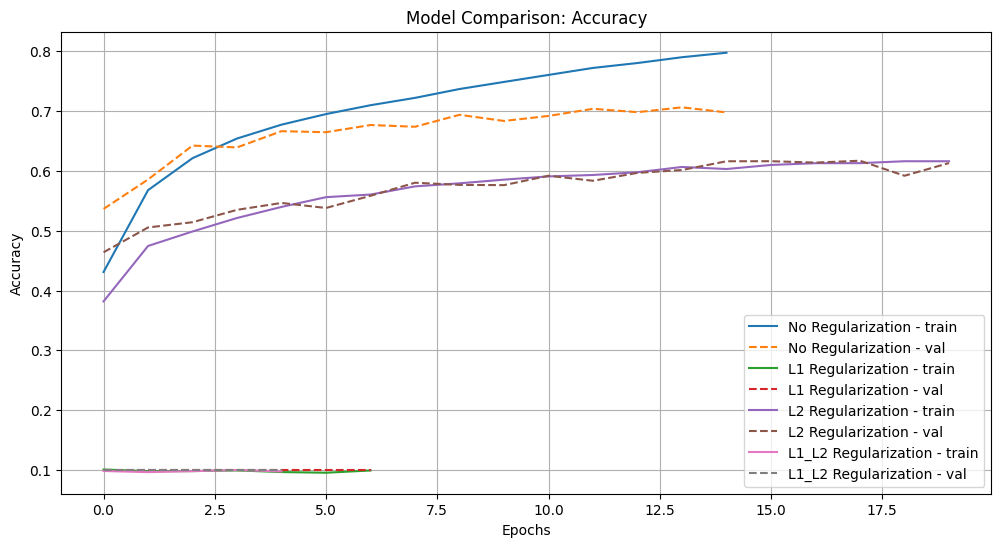

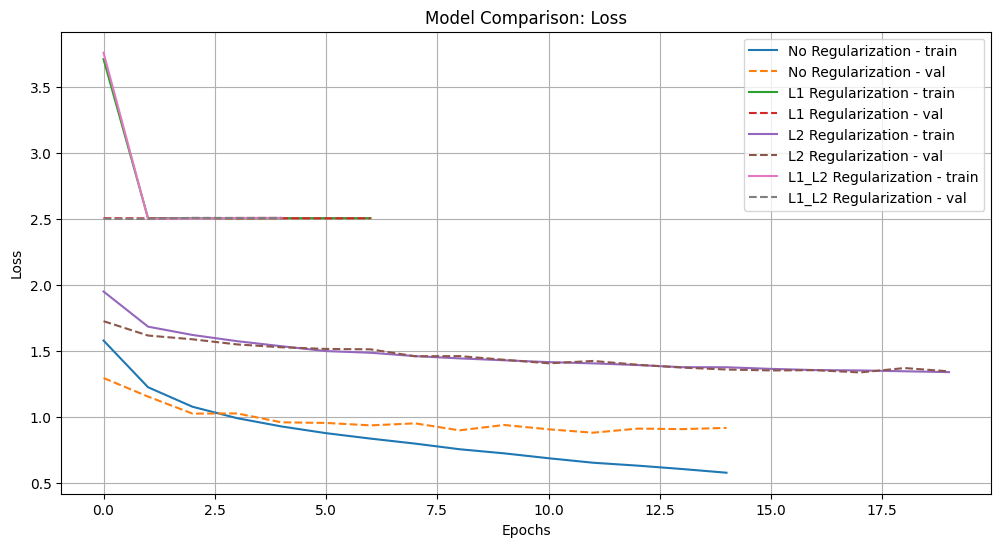

In [6]:
def plot_histories(histories, metric='accuracy'):
    plt.figure(figsize=(12, 6))
    for name, history in histories.items():
        plt.plot(history.history[metric], label=f'{name} - train')
        plt.plot(history.history[f'val_{metric}'], linestyle='--', label=f'{name} - val')
    plt.title(f'Model Comparison: {metric.capitalize()}')
    plt.xlabel('Epochs')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)
    plt.show()

plot_histories(histories, 'accuracy')
plot_histories(histories, 'loss')

## Evaluate and Summarize Final Accuracy

In [7]:
final_results = []
for name, model in models.items():
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    final_results.append([name, round(test_loss, 4), round(test_acc * 100, 2)])

print(tabulate(final_results, headers=["Model", "Test Loss", "Test Accuracy (%)"]))

Model                   Test Loss    Test Accuracy (%)
--------------------  -----------  -------------------
No Regularization          0.8829                70.38
L1 Regularization          2.5026                10
L2 Regularization          1.3384                61.7
L1_L2 Regularization       2.4995                10


# L1 and L2 Regularization

📘 Overview

This Colab notebook demonstrates the impact of L1 (Lasso), L2 (Ridge), and combined L1_L2 regularization in a Convolutional Neural Network (CNN) using TensorFlow and Keras. The model is trained on the CIFAR-10 dataset to illustrate how regularization improves generalization.

🧪 Objective

To understand how L1, L2, and L1_L2 regularization techniques help in:

- Reducing overfitting

- Encouraging sparsity (L1)

- Penalizing large weights (L2)

- Balancing sparsity and stability (L1_L2)

🛠️ Implementation Details

- Dataset: CIFAR-10

- Model Architecture: CNN with 2 Conv2D layers, MaxPooling, Flatten, Dense layers

- Regularization Strategies:

     No Regularization

    L1: regularizers.l1(0.01)

    L2: regularizers.l2(0.01)

    L1_L2: regularizers.l1_l2(l1=0.01, l2=0.01)

- Training Setup:

    Epochs: 10

    Batch Size: 64

    Optimizer: Adam

    Loss: Sparse Categorical Crossentropy

📈 Results

Each model's validation accuracy over 10 epochs is plotted to show how each regularization technique affects performance:

- No Regularization: High training accuracy, but susceptible to overfitting.

- L1 Regularization: Promotes sparsity in weights, helps reduce overfitting.

- L2 Regularization: Reduces the magnitude of weights, stabilizes learning.

- L1_L2 Regularization: Combines benefits of L1 and L2; good balance of sparsity and control.

🧠 Insights

- L1 regularization is ideal for feature selection and sparse models.

- L2 is better suited for scenarios where we want to avoid very large weights.

- L1_L2 is used when both weight sparsity and regularized training are desired.

Regularization is a critical tool to enhance generalization, especially with limited data or complex models.



